## Support Vector Machines (SVMs): The Primal Optimization Problem

In this notebook, we will optimize the SVMs primal objective with stochastic subgradient descent.

Check out the [blog post](https://github.com/didarulilm/ml-notebooks) where I explained how to derive the optimization problem from scratch.


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [76]:
data = pd.read_csv("../data/non_separable_data.csv")
data

,Feature 1,Feature 2,Label
0,3.764052,2.400157,0.0
1,0.729515,2.969397,0.0
2,0.826877,3.943621,0.0
3,1.586381,1.252545,0.0
4,3.922942,3.480515,0.0
...,...,...,...
295,-0.647181,0.472247,1.0
296,0.930408,-0.175316,1.0
297,-1.421920,1.997956,1.0
298,-0.856549,-1.541587,1.0


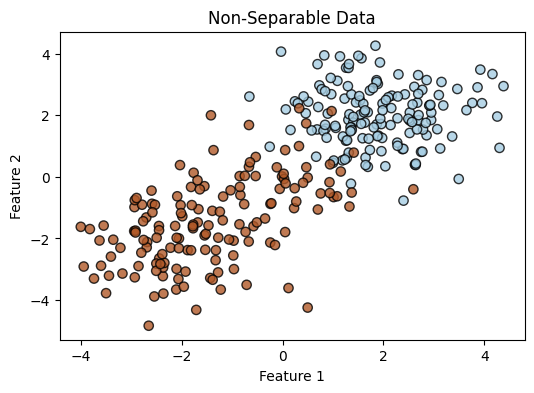

In [77]:
features = data.drop("Label", axis=1).values
labels = data["Label"].values
transformed_labels = np.where(labels == 1, 1, -1)

# Plot the dataset
plt.figure(figsize=(6, 4))
plt.scatter(
    features[:, 0],
    features[:, 1],
    c=(transformed_labels == 1).astype(int),
    cmap="Paired",
    edgecolors="k",
    s=45,
    alpha=0.8,
)
plt.title("Non-Separable Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Split the dataset into training and test set
features_train, features_test, labels_train, labels_test = train_test_split(
    features, transformed_labels, test_size=0.2, random_state=42
)

### Cost Function, Subgradient, and Inference

We know our cost function $J(w,b)$ is defined as

$$
J(w,b)={\frac{\lambda}{2}||w||^2} + \frac{1}{M}\sum_{i=1}^{M} \max(0, 1 - y_i(w^Tx_i+b))
$$

The subgradient of the cost function with respect to $w$ is given by

$$
{\nabla}_{w}J(w,b) = \lambda w + \frac{1}{M}\sum_{i=1}^{M}\begin{cases}
-  y_ix_i&\quad \text{if } y_i(w^Tx_i+b) < 1\\
0 &\quad \text{otherwise}
\end{cases}
$$

and the subgradient with respect to $b$ is given by

$$
\frac{\partial}{\partial b}J(w,b)=\frac{1}{M}\sum_{i=1}^{M}\begin{cases}
-  y_i&\quad \text{if } y_i(w^Tx_i+b) < 1\\
0 &\quad \text{otherwise}
\end{cases}
$$

After training, we can evaluate the model on unseen data. For any test instance $x_{test}$, the predicted label is simply:
$$\hat y​=sign(w^Tx_{test}+b​)$$


In [ ]:
class PrimalSVM:
    def __init__(self, reg_param, lr=0.001, epochs=1000, batch_size=1) -> None:
        """
        Initialize the primal SVM model
        """
        self.reg_param = reg_param
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.weights = None
        self.bias = 0

    def _compute_cost(self, features, labels) -> float:
        """
        Compute the scalar value of the cost function
        """
        n_samples = features.shape[0]

        if self.weights is None:
            raise ValueError("Model not trained yet: set weights first.")

        # Compute the hinge loss
        scores = np.dot(features, self.weights) + self.bias
        y_scores = labels * scores
        hinge_loss = np.maximum(0, 1 - y_scores)
        loss_term = np.sum(hinge_loss) / n_samples

        # Compute the overall cost
        regularizer = 0.5 * self.reg_param * np.dot(self.weights, self.weights)
        cost = regularizer + loss_term

        return float(cost)